## Importing the needed library

In [1]:
import os

from utils import *
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt


from models.Autoencoder import Conv1DDenoiser

2025-10-10 12:25:06.402467: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Generating the dataset
The data will contain numbers between 0 and 2pi, the sine function will be defined in rad.
A random uniform error is added to the sine values to give the dataset a bit of variability and see how the model will perform.
The error is centred with a mean of 0 and std 0f 0.1. This is chosen such that 95% of the error is -0.2 and 0.+2.

In [2]:
train_samples = 500
test_samples = 300
val_samples = 100
# Generate data
x_train, s_train = generate_data(num_samples=train_samples)
x_test, s_test = generate_data(num_samples=test_samples)

x_validate, s_validate = generate_data(num_samples=val_samples)

In [180]:
x_train.shape

(500,)

### Reshape for array input

In [26]:
X_train = x_train.reshape(1, train_samples, 1)
S_train = s_train.reshape(1, train_samples, 1)
X_test = x_test.reshape(1, test_samples, 1)
S_test = s_test.reshape(1, test_samples, 1)

X_validate = x_validate.reshape(1, val_samples, 1)
S_validate = s_validate.reshape(1, val_samples, 1)




In [27]:
X_train.shape

(1, 500, 1)

In [5]:
model_name = "seq_input"

In [9]:
if model_name == "autoencoder_filter":
    model = Conv1DDenoiser()
    dummy_input = tf.random.normal([1, 1024, 1])  
    output = model(dummy_input)
    print(output.shape)
elif model_name == "neural_filter":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
elif model_name == "adaptive_neural":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Conv1D(16, kernel_size=9, padding='same'),
        tf.keras.layers.Dense(1)
    ])
elif model_name == "conv1_no_array":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=9, padding='same', activation="relu", input_shape=(1000, 1)),
            tf.keras.layers.Conv1D(32, kernel_size=5, padding='same', activation="relu"),
            tf.keras.layers.Dense(1)
        ])
elif model_name == "conv_downsize":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=5, padding='same', activation="relu", input_shape=(500, 1)),
            Dense(1)
        ])
elif model_name == "scalar_conv_input":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=5, padding='same', activation="relu", input_shape=(10, 1)),
            # Dense(1),
            # tf.keras.layers.Lambda(lambda x: x[:, -1, :])
            tf.keras.layers.Dense(1),
            tf.keras.layers.Cropping1D(cropping=(9, 0)),  # keep only last timestep
            tf.keras.layers.Flatten()                     # output shape -> (1,)
        ])
else:
    # Build the neural network
    model = Sequential([
        layers.Dense(64, activation='relu', input_shape=(1,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])

/home/sergiusz/ML_Filter/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-10 08:41:21.121118: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-10-10 08:41:21.121186: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-10-10 08:41:21.121192: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-10-10 08:41:21.121197: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun 

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

In [158]:
print("X_train:", X_train.shape)
print("S_train:", S_train.shape)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


X_train: (490, 10, 1)
S_train: (490, 1)
Model input shape: (None, 10, 1)
Model output shape: (None, 1)


## Normal training

In [153]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=["mae"])

# Train the model
history = model.fit(X_train, S_train, epochs=200, batch_size=32, validation_data=(X_validate, S_validate))




Epoch 1/200
 1/16 ━━━━━━━━━━━━━━━━━━━━ 8s 566ms/step - loss: 1.1698 - mae: 0.9444

ValueError: Input 0 of layer "functional_4" is incompatible with the layer: expected shape=(None, 10, 1), found shape=(None, 100)

In [ ]:
# Evaluate the model
# loss = model.evaluate(X_test[0], S_test[0])
# print(f"Test Loss: {loss}")

s_pred = model.predict(X_test)



## New sequence training

In [166]:
import numpy as np

def generate_dataset(n_samples=10000, window=10, fs=1000):
    X, y = [], []
    for _ in range(n_samples):
        f = np.random.uniform(5, 50)        # random frequency
        phase = np.random.uniform(0, 2*np.pi)
        t = np.arange(window) / fs
        clean = np.sin(2*np.pi*f*t + phase)
        noise = np.random.normal(0, 0.2, window)
        noisy = clean + noise
        X.append(noisy)
        y.append(clean[-1])  # current sample target
    X = np.array(X)[..., None]
    y = np.array(y)[..., None]
    return X, y

X, y = generate_dataset()
X_test, y_test = generate_dataset(n_samples=1000)
history = model.fit(X, y, epochs=20, batch_size=64, validation_split=0.1)


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0161 - mae: 0.0976 - val_loss: 0.0164 - val_mae: 0.0996
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 - mae: 0.0977 - val_loss: 0.0164 - val_mae: 0.0980
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0162 - mae: 0.0978 - val_loss: 0.0165 - val_mae: 0.0981
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 - mae: 0.0976 - val_loss: 0.0165 - val_mae: 0.1002
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 - mae: 0.0975 - val_loss: 0.0165 - val_mae: 0.0994
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160 - mae: 0.0976 - val_loss: 0.0167 - val_mae: 0.0990
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0160 - mae: 0.0975 - val_loss: 0.0171 - val_mae: 0.0990
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160 - mae: 0.0973 - val_loss: 0.0167 - val_mae: 0.0982
Epoch 9/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [170]:
print(X.shape, y.shape)
print(X_test.shape, y_test.shape)

(10000, 10, 1) (10000, 1)
(1000, 10, 1) (1000, 1)


# Training Results

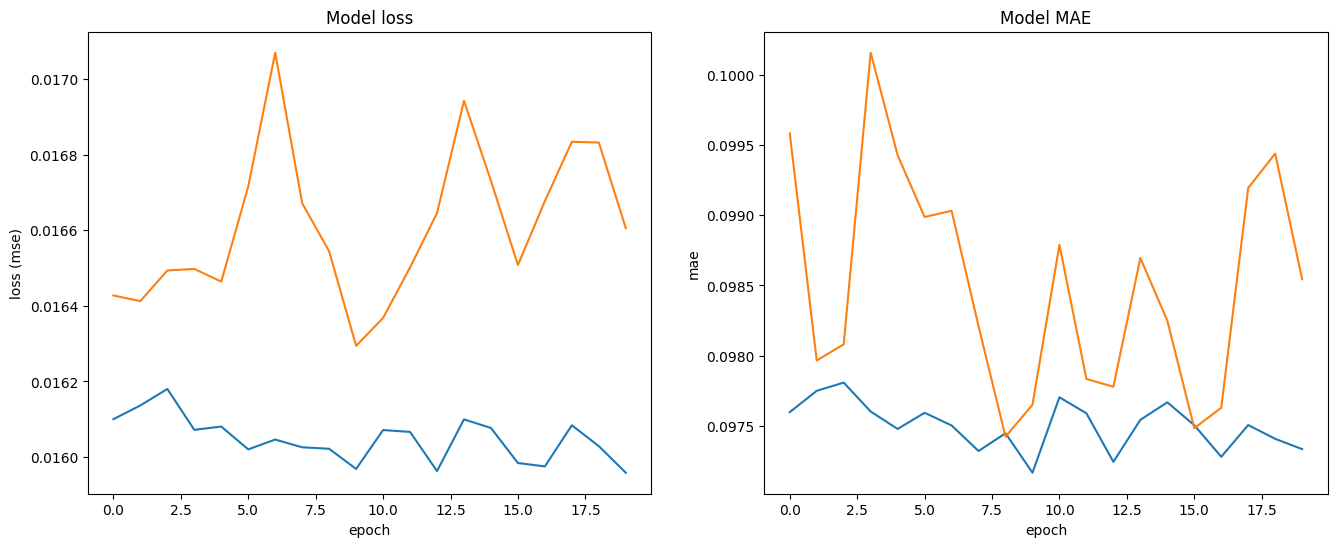

In [167]:
fig, axes = plt.subplots( 1, 2, figsize=(16,6))

axes[0].plot(history.history["loss"], label="training_loss")
axes[0].plot(history.history["val_loss"], label="validation_loss")
axes[0].set_title("Model loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss (mse)")

axes[1].plot(history.history["mae"], label="training_mae")
axes[1].plot(history.history["val_mae"], label="validation_loss")
axes[1].set_title("Model MAE")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mae")

plt.savefig(f'results/{model_name}_training.png')
plt.show()

# Scalar input

ValueError: x and y can be no greater than 2D, but have shapes (1,) and (1, 300, 1)

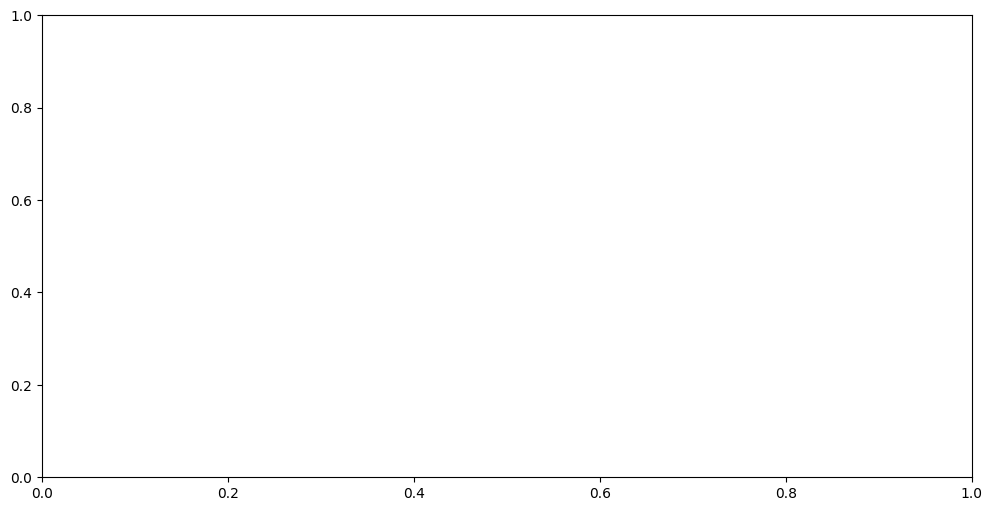

In [133]:
plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(s_test, label='Clean Signal')
plt.plot(s_pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

# Array input

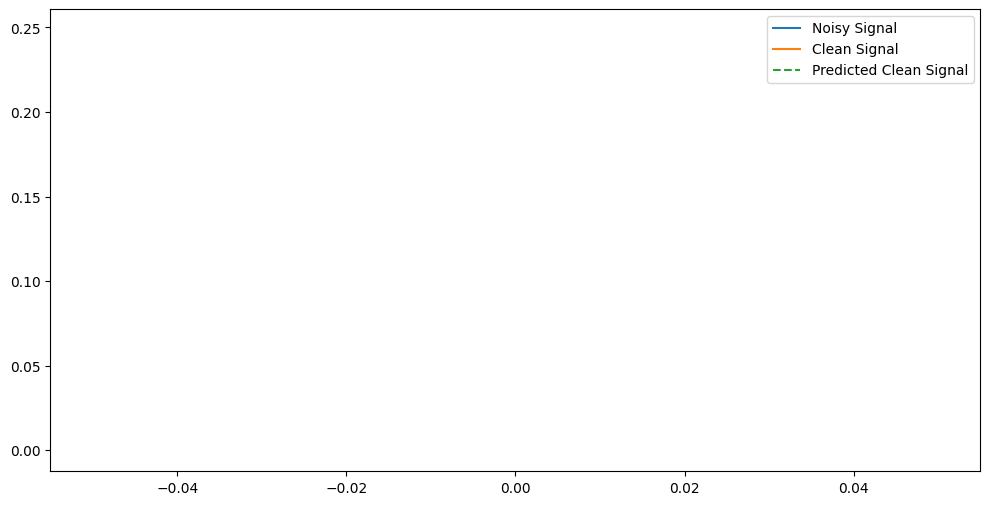

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(x_test[0], label='Noisy Signal')
plt.plot(s_test[0], label='Clean Signal')
plt.plot(s_pred[0], label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

# Sequnce input

In [141]:
seq_list = []
for test in X_test:
    s_pred = model.predict(test)
    seq_list.append(s_pred.mean())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

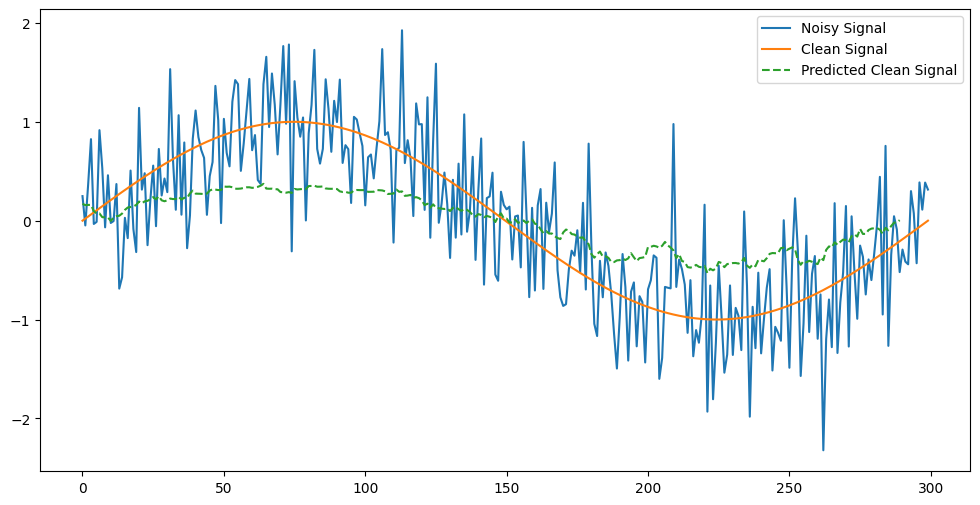

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(s_test, label='Clean Signal')
plt.plot(seq_list, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

# New sequence input

In [168]:
y_pred = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


ValueError: x and y can be no greater than 2D, but have shapes (1000,) and (1000, 10, 1)

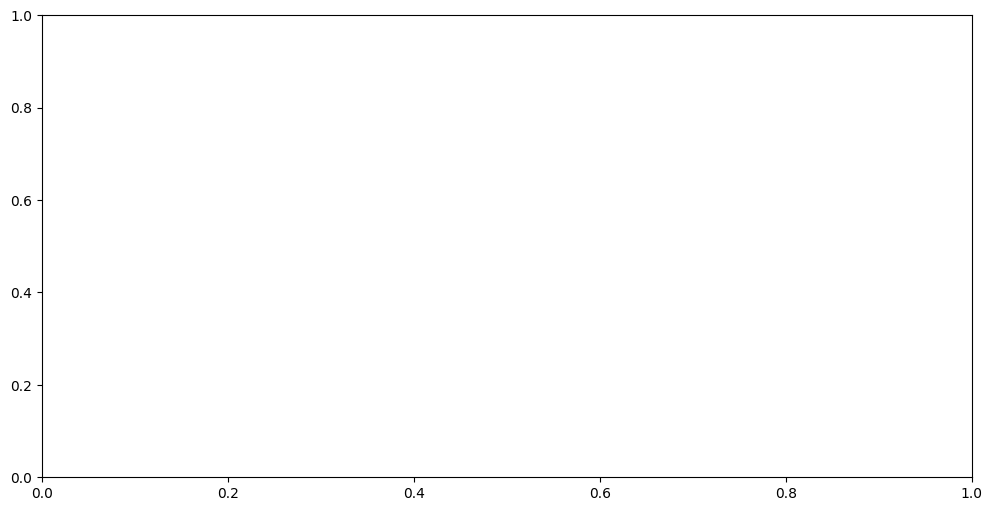

In [169]:
plt.figure(figsize=(12, 6))
plt.plot(X_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(seq_list, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

## Saving the keras model

In [12]:
model.save(f'checkpoints/{model_name}.keras')


In [59]:
model_name = "best_sequence_model"

In [60]:
#Loading if needed
model = tf.keras.models.load_model(f'checkpoints/{model_name}.keras', safe_mode=False)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 10, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 10, 1)          │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,397 (5.46 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 932 (3.64 KB)

## Converting the model to tflite

In [31]:
def generate_data(num_samples=1000, noise_factor=0.5):
    np.random.seed(42)
    t = np.linspace(0, 1, num_samples, dtype=np.float32)
    s = np.sin(2 * np.pi * t, dtype=np.float32)  # Clean signal
    n = noise_factor * np.random.normal(size=num_samples)  # Noise
    x = s + n  # Noisy signal
    x.astype(dtype=np.float32)
    s.astype(dtype=np.float32)
    return x, s


def create_seq(x:np.array, seq_len=10, n_samples=1000):
    # seq = np.zeros(shape=(seq_len, n_samples//seq_len))
    new_x = []
    seq = []
    for i in range(seq_len, n_samples):
        seq.append(x[i-seq_len:i])
    seq = np.array(seq, dtype=np.float32)
    new_x.append(seq)
    return np.array(new_x)
        

In [49]:
n_samples = 1000
test_data, _ = generate_data(num_samples=n_samples)
test_data = create_seq(test_data, n_samples=n_samples)
# test_data = np.squeeze(test_data)

In [51]:
test_data.shape

(1, 990, 10)

In [42]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

In [43]:
input = model.input_shape

In [52]:
input

(None, 10, 1)

In [63]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.optimizations = []
converter.allow_custom_ops = False
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]



# For full integer quantization
def representative_dataset_gen():
  # Get sample input data as a numpy array in a method of your choosing.
  n_samples = 1000
  seq_len = 10
  test_data, _ = generate_data(num_samples=n_samples)
  test_data = create_seq(test_data, seq_len=seq_len, n_samples=n_samples)
  # test_data = np.squeeze(test_data)
  
  for i in range (n_samples- seq_len): # temp fix as the last seq isn't saved
    yield [test_data[i]]

# Ensure integer input/output
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8
# converter.representative_dataset = representative_dataset_gen

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp1vy28x9j/assets


INFO:tensorflow:Assets written to: /tmp/tmp1vy28x9j/assets


Saved artifact at '/tmp/tmp1vy28x9j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137158108111168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137158108111696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137158108104128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137158109385600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137158109393872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137158109394928: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1760100178.068801   88142 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1760100178.068816   88142 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-10 14:42:58.068923: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1vy28x9j
2025-10-10 14:42:58.069332: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-10 14:42:58.069338: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp1vy28x9j
2025-10-10 14:42:58.072561: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-10 14:42:58.090084: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp1vy28x9j
2025-10-10 14:42:58.096559: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 27637 microseconds.


# AI BrainRot quantization

In [56]:
import numpy as np
import tensorflow as tf

# --- utilities (fixed) ---
def generate_data(num_samples=1000, noise_factor=0.5):
    np.random.seed(42)
    t = np.linspace(0, 1, num_samples, dtype=np.float32)
    s = np.sin(2 * np.pi * t).astype(np.float32)  # clean signal
    n = (noise_factor * np.random.normal(size=num_samples)).astype(np.float32)
    x = (s + n).astype(np.float32)
    return x, s

def create_seq(x: np.array, seq_len=10, n_samples=1000):
    """
    Return array of shape (n_sequences, seq_len, 1), dtype float32
    where n_sequences = n_samples - seq_len
    """
    n_sequences = n_samples - seq_len
    seqs = np.zeros((n_sequences, seq_len, 1), dtype=np.float32)
    for i in range(seq_len, n_samples):
        seqs[i - seq_len, :, 0] = x[i - seq_len:i]
    return seqs

# --- quick sanity: check model input shape ---
print("Model input shape:", model.input_shape)  # e.g. (None, 10, 1)
# If your model input isn't (None, 10, 1), adapt seq_len and reshape accordingly.

# --- create example dataset and test that shapes match ---
n_samples = 1000
seq_len = 10
x, _ = generate_data(num_samples=n_samples)
seqs = create_seq(x, seq_len=seq_len, n_samples=n_samples)
print("seqs.shape:", seqs.shape)  # expected (n_sequences, 10, 1)

# --- Representative dataset generator for TFLite ---
def representative_dataset_gen():
    # Use a subset (or random examples) — yield one batch at a time matching model input.
    # The converter expects a generator that yields lists (one element per input tensor).
    n_to_yield = min(100, seqs.shape[0])
    for i in range(n_to_yield):
        sample = seqs[i]                 # shape (seq_len, 1)
        sample = np.expand_dims(sample, axis=0).astype(np.float32)  # shape (1, seq_len, 1)
        yield [sample]

# --- Configure converter (example: post-training quantization to int8 not forced here) ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# If you want full integer quantization for edge devices, uncomment & ensure shapes/dtypes correct:
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

converter.representative_dataset = representative_dataset_gen

tflite_model = converter.convert()
print("Conversion succeeded: tflite model size", len(tflite_model), "bytes")


Model input shape: (None, 10, 1)
seqs.shape: (990, 10, 1)
INFO:tensorflow:Assets written to: /tmp/tmpvy46h9zr/assets


INFO:tensorflow:Assets written to: /tmp/tmpvy46h9zr/assets


Saved artifact at '/tmp/tmpvy46h9zr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137159706044624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137159705640304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137159651352720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137159705626576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137159705627456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137159648143040: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/sergiusz/ML_Filter/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Conversion succeeded: tflite model size 6920 bytes


W0000 00:00:1760097689.758359   88142 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1760097689.758384   88142 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-10 14:01:29.758610: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvy46h9zr
2025-10-10 14:01:29.759176: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-10 14:01:29.759270: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpvy46h9zr
2025-10-10 14:01:29.767117: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-10 14:01:29.807838: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpvy46h9zr
2025-10-10 14:01:29.823705: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 65078 microseconds.
fully_quantize: 0, inference_type: 6, input_i

In [57]:
model_name = "quantized"

## Converting the model to the c, TFlite micro format for the microcontroller

In [64]:
# Save as .tflite file
with open(f"results/{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

with open(f"{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

# Breaking the byte in several lines to fit better in the c header file
tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in tflite_model], len(tflite_model)//8)

C_HEADER_DIR = "STM_project"
newline = ",\n    "  # separator to avoid new line character

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}/{model_name.lower()}.h", "w").write(
f"""
#ifndef {model_name.upper()}_H
#define {model_name.upper()}_H

const unsigned int {model_name.lower()}_len = {len(tflite_model)};

const unsigned char {model_name.lower()}[{len(tflite_model)}] = {{
    {newline.join([", ".join(line) for line in tflite_model_split_line])}
}};

#endif // {model_name.upper()}_H
"""
)


45723

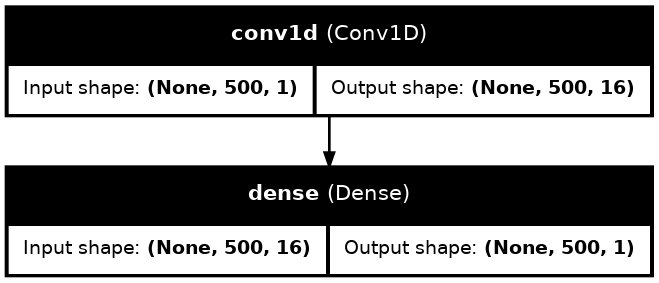

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='model.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,   # show inner layers if nested
           dpi=96)
